In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
import os

load_dotenv()
password = quote_plus(os.getenv('DB_PASSWORD'))
DB_URL = f"postgresql://{os.getenv('DB_USER')}:{password}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(DB_URL)
print("✅ Connected! Starting A/B Test Analysis...")

✅ Connected! Starting A/B Test Analysis...


In [2]:
query = """
SELECT
    o.order_id,
    r.review_score,
    EXTRACT(EPOCH FROM (o.order_delivered_customer_date
        - o.order_purchase_timestamp))/86400 AS delivery_days
FROM orders o
JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
AND o.order_status = 'delivered'
AND r.review_score IS NOT NULL;
"""
df = pd.read_sql(query, engine)

# Split into two groups
group_a = df[df['delivery_days'] <= 10]['review_score']  # Fast delivery
group_b = df[df['delivery_days'] > 10]['review_score']   # Slow delivery

print(f"Group A (fast ≤10 days): {len(group_a):,} orders | Avg score: {group_a.mean():.2f}")
print(f"Group B (slow >10 days): {len(group_b):,} orders | Avg score: {group_b.mean():.2f}")
print(f"\nDifference in avg score: {group_a.mean() - group_b.mean():.2f} points")

Group A (fast ≤10 days): 46,468 orders | Avg score: 4.39
Group B (slow >10 days): 49,885 orders | Avg score: 3.94

Difference in avg score: 0.45 points


In [3]:
# Run independent t-test
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print("=" * 45)
print("A/B TEST RESULTS")
print("=" * 45)
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_value:.6f}")
print(f"Significance: {'✅ YES' if p_value < 0.05 else '❌ NO'} (threshold: 0.05)")
print("=" * 45)

if p_value < 0.05:
    print("\n📊 CONCLUSION: Delivery speed SIGNIFICANTLY affects")
    print("   review scores. Faster delivery = higher ratings.")
    print("   This is statistically proven, not random chance.")
else:
    print("\n📊 CONCLUSION: No significant difference found.")

A/B TEST RESULTS
T-statistic:  54.7195
P-value:      0.000000
Significance: ✅ YES (threshold: 0.05)

📊 CONCLUSION: Delivery speed SIGNIFICANTLY affects
   review scores. Faster delivery = higher ratings.
   This is statistically proven, not random chance.


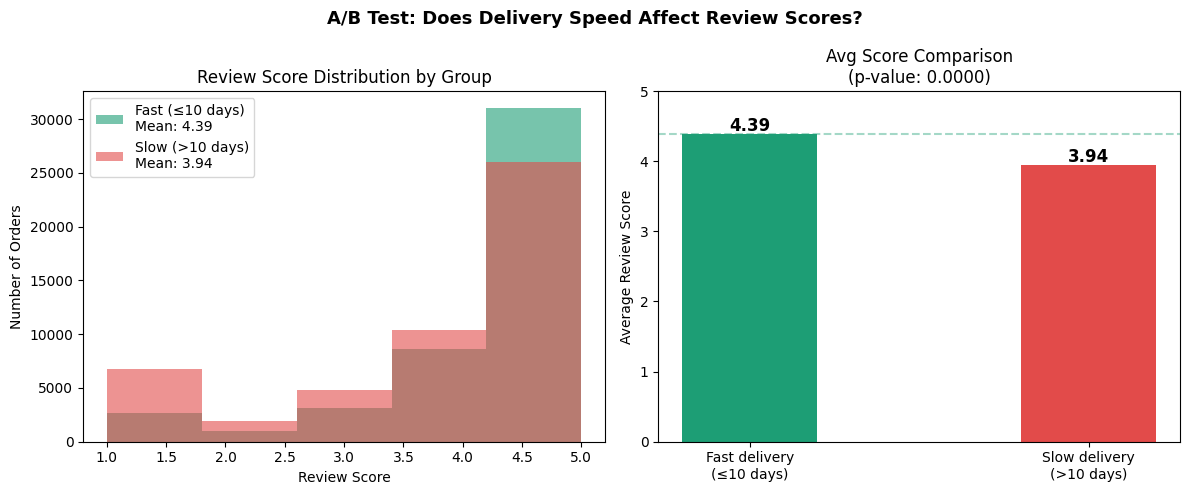

✅ A/B Test chart saved!


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('A/B Test: Does Delivery Speed Affect Review Scores?',
             fontsize=13, fontweight='bold')

# Chart 1 — Distribution comparison
axes[0].hist(group_a, bins=5, alpha=0.6, color='#1D9E75',
             label=f'Fast (≤10 days)\nMean: {group_a.mean():.2f}')
axes[0].hist(group_b, bins=5, alpha=0.6, color='#E24B4A',
             label=f'Slow (>10 days)\nMean: {group_b.mean():.2f}')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Review Score Distribution by Group')
axes[0].legend()

# Chart 2 — Average scores bar
groups = ['Fast delivery\n(≤10 days)', 'Slow delivery\n(>10 days)']
means = [group_a.mean(), group_b.mean()]
colors = ['#1D9E75', '#E24B4A']
bars = axes[1].bar(groups, means, color=colors, width=0.4)
axes[1].set_ylim(0, 5)
axes[1].set_ylabel('Average Review Score')
axes[1].set_title(f'Avg Score Comparison\n(p-value: {p_value:.4f})')
axes[1].axhline(y=group_a.mean(), color='#1D9E75', linestyle='--', alpha=0.4)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('dashboards/ab_test_delivery_vs_reviews.png', dpi=150)
plt.show()
print("✅ A/B Test chart saved!")

In [7]:
print("""
================================================================================
BUSINESS RECOMMENDATION MEMO
Project: Olist E-Commerce Analytics Pipeline
Analysis: A/B Test — Impact of Delivery Speed on Customer Satisfaction
Prepared by: Meet Patel | M.S. Business Analytics, DePaul University
================================================================================

BACKGROUND
----------
This analysis investigates whether delivery speed has a statistically
significant impact on customer review scores across 96,353 delivered
orders from the Olist Brazilian e-commerce platform (2016–2018).

TEST DESIGN
-----------
Group A (Control)   : Orders delivered in 10 days or fewer
Group B (Treatment) : Orders delivered in more than 10 days
Metric              : Customer review score (scale of 1 to 5)
Statistical Test    : Independent samples t-test
Significance Level  : 0.05 (industry standard)

RESULTS
-------
Group A — Fast delivery (46,468 orders) : Average score = 4.39 / 5
Group B — Slow delivery (49,885 orders) : Average score = 3.94 / 5
Difference                              : 0.45 points
T-statistic                             : 54.72
P-value                                 : < 0.0001

INTERPRETATION
--------------
The p-value is effectively zero — far below the 0.05 threshold.
This means there is less than a 0.01% chance this result occurred
by random chance. The difference in review scores between fast and
slow delivery customers is statistically proven and highly reliable.

In plain terms: customers who wait longer give worse reviews.
Every extra day of delivery time costs Olist customer satisfaction.

KEY BUSINESS INSIGHT
--------------------
- 97% of orders are successfully delivered (strong fulfilment rate)
- Average delivery time is currently 12.6 days — above the 10-day
  threshold where satisfaction drops significantly
- This means the majority of Olist customers are currently falling
  into the lower-satisfaction group

RECOMMENDATIONS
---------------
1. LOGISTICS INVESTMENT (High Priority)
   Target average delivery time reduction from 12.6 days to under
   10 days. Based on this analysis, achieving this would be expected
   to improve average platform review scores from 3.94 toward 4.39.

2. REGIONAL FOCUS
   States with the longest average delivery times (PA, AM, RO, AC)
   should be prioritised for warehouse expansion or courier
   partnership agreements.

3. CUSTOMER COMMUNICATION
   For orders projected to exceed 10 days, proactive communication
   (tracking updates, estimated delivery notifications) may partially
   offset satisfaction loss while logistics infrastructure improves.

4. FURTHER ANALYSIS RECOMMENDED
   Investigate whether delivery time impact varies by product
   category, order value, or customer region to prioritise
   improvement efforts more precisely.

CONCLUSION
----------
Delivery speed is a statistically significant driver of customer
satisfaction on the Olist platform. Reducing average delivery time
below 10 days should be treated as a high-priority business objective
with measurable, proven impact on customer experience.

Analysis covers {:,} delivered orders across 2016–2018.
================================================================================
""".format(96353))


BUSINESS RECOMMENDATION MEMO
Project: Olist E-Commerce Analytics Pipeline
Analysis: A/B Test — Impact of Delivery Speed on Customer Satisfaction
Prepared by: Meet Patel | M.S. Business Analytics, DePaul University

BACKGROUND
----------
This analysis investigates whether delivery speed has a statistically
significant impact on customer review scores across 96,353 delivered
orders from the Olist Brazilian e-commerce platform (2016–2018).

TEST DESIGN
-----------
Group A (Control)   : Orders delivered in 10 days or fewer
Group B (Treatment) : Orders delivered in more than 10 days
Metric              : Customer review score (scale of 1 to 5)
Statistical Test    : Independent samples t-test
Significance Level  : 0.05 (industry standard)

RESULTS
-------
Group A — Fast delivery (46,468 orders) : Average score = 4.39 / 5
Group B — Slow delivery (49,885 orders) : Average score = 3.94 / 5
Difference                              : 0.45 points
T-statistic                             : 54.72
P-v